## Computational Complexity of the Transformer

The Transformer architecture (Vaswani et al., 2017) has quadratic complexity in terms of sequence length due to its **self-attention mechanism**.
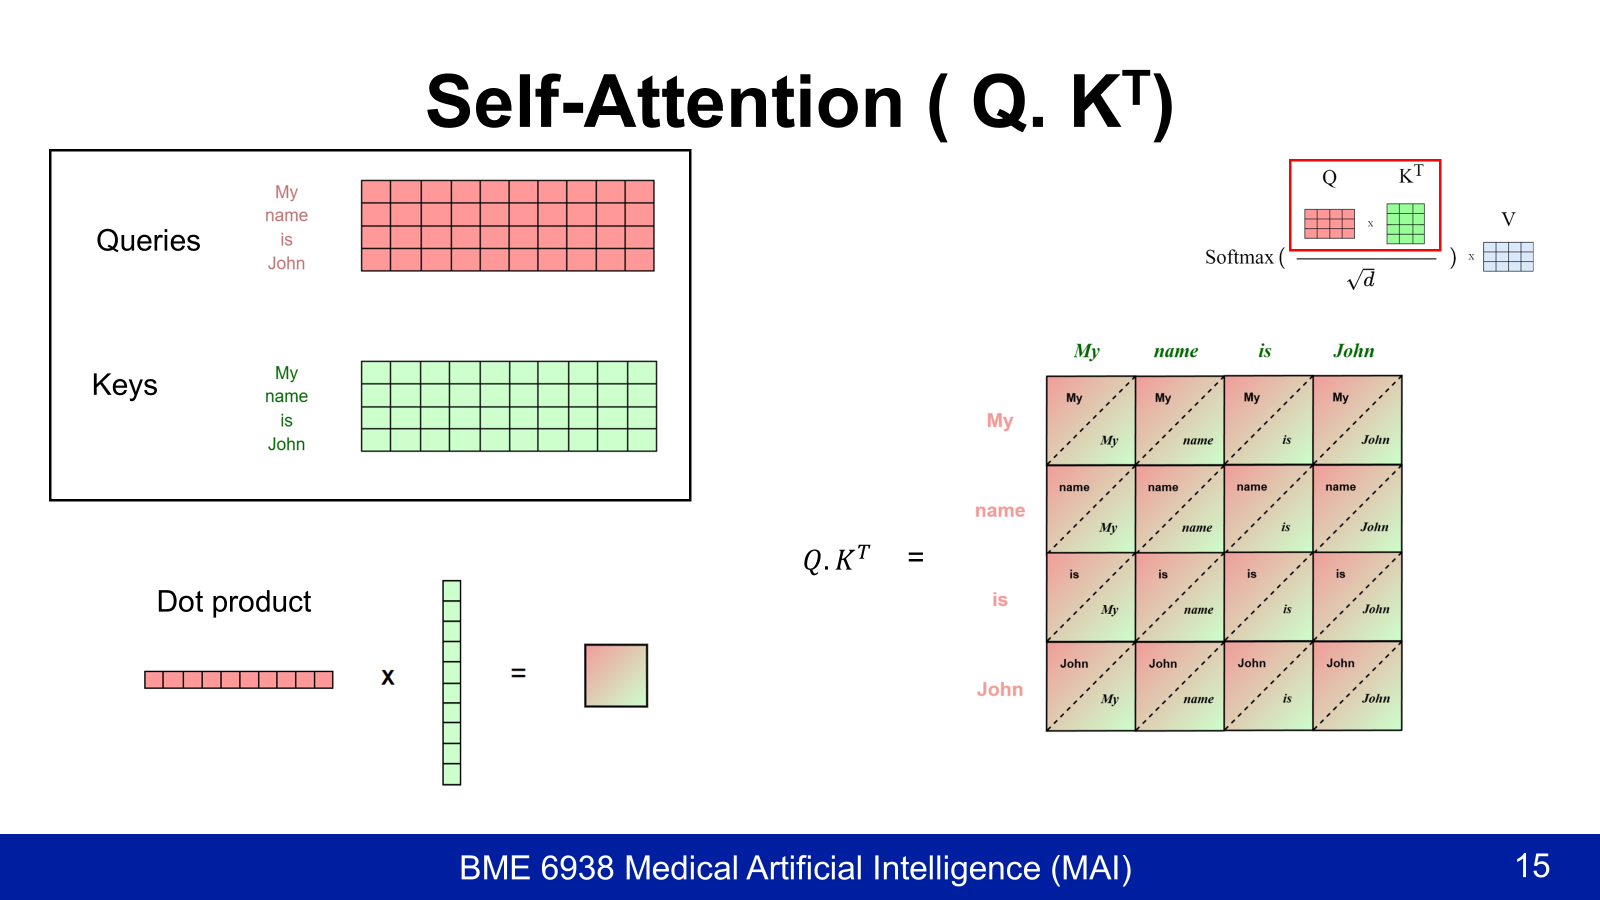](attachment:image-2.png)
### Self-Attention Complexity

For a sequence of length $n$ and model dimension $d$:

| Operation | Time Complexity | Space Complexity |
|-----------|----------------|-----------------|
| Self-Attention | $O(n^2 \cdot d)$ | $O(n^2 + n \cdot d)$ |
| Feed-Forward | $O(n \cdot d^2)$ | $O(n \cdot d)$ |
| **Total (per layer)** | $O(n^2 \cdot d + n \cdot d^2)$ | $O(n^2 + n \cdot d^2)$ |

### Breakdown

**Self-Attention** computes pairwise interactions between all tokens:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- The $QK^T$ product produces an $n \times n$ attention matrix → $O(n^2 \cdot d)$
- This is the **bottleneck** for long sequences

**Feed-Forward layers** dominate only when $d \gg n$:
$$O(n \cdot d^2)$$

### Practical Implications

- For short sequences ($n < 512$): attention cost is manageable
- For long sequences ($n \sim 10{,}000+$): quadratic cost becomes prohibitive
- This motivated efficient attention variants (e.g., **Longformer** $O(n)$, **Linformer** $O(n)$, **Performer** $O(n \log n)$)

### vs. RNNs

| Model | Time | Space | Parallelizable |
|-------|------|-------|----------------|
| RNN | $O(n \cdot d^2)$ | $O(d)$ | No |
| Transformer | $O(n^2 \cdot d)$ | $O(n^2)$ | Yes |

Transformers trade **sequential computation** for **memory**, enabling massive parallelization on GPUs.

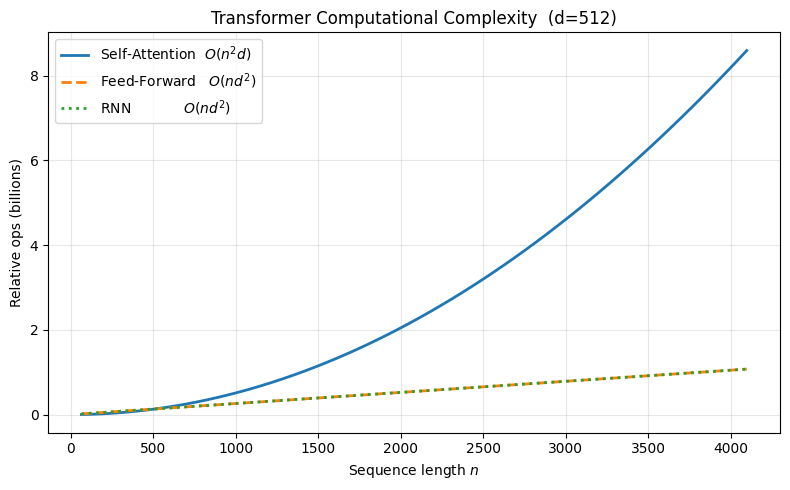

At n=512:  attention=134.2M ops,  FF=134.2M ops
At n=2048: attention=2147.5M ops, FF=536.9M ops


In [2]:
import numpy as np
import matplotlib.pyplot as plt

seq_lengths = np.arange(64, 4097, 64)
d_model = 512

attention_cost = seq_lengths**2 * d_model       # O(n^2 * d)
ff_cost        = seq_lengths * d_model**2        # O(n * d^2)
rnn_cost       = seq_lengths * d_model**2        # O(n * d^2)  — same scaling as FF

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(seq_lengths, attention_cost / 1e9, label=r"Self-Attention  $O(n^2 d)$", linewidth=2)
ax.plot(seq_lengths, ff_cost / 1e9,        label=r"Feed-Forward   $O(n d^2)$",  linewidth=2, linestyle="--")
ax.plot(seq_lengths, rnn_cost / 1e9,       label=r"RNN            $O(n d^2)$",  linewidth=2, linestyle=":")
ax.set_xlabel("Sequence length $n$")
ax.set_ylabel("Relative ops (billions)")
ax.set_title(f"Transformer Computational Complexity  (d={d_model})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At n=512:  attention={512**2 * d_model / 1e6:.1f}M ops,  FF={512 * d_model**2 / 1e6:.1f}M ops")
print(f"At n=2048: attention={2048**2 * d_model / 1e6:.1f}M ops, FF={2048 * d_model**2 / 1e6:.1f}M ops")

## Tokenization 

In [3]:
from transformers import AutoTokenizer
import torch
name = "distilbert/distilbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(name) # convenient! Defaults to Fast
print(tokenizer)

/blue/bme6938/share/conda/pt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BertTokenizer(name_or_path='distilbert/distilbert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


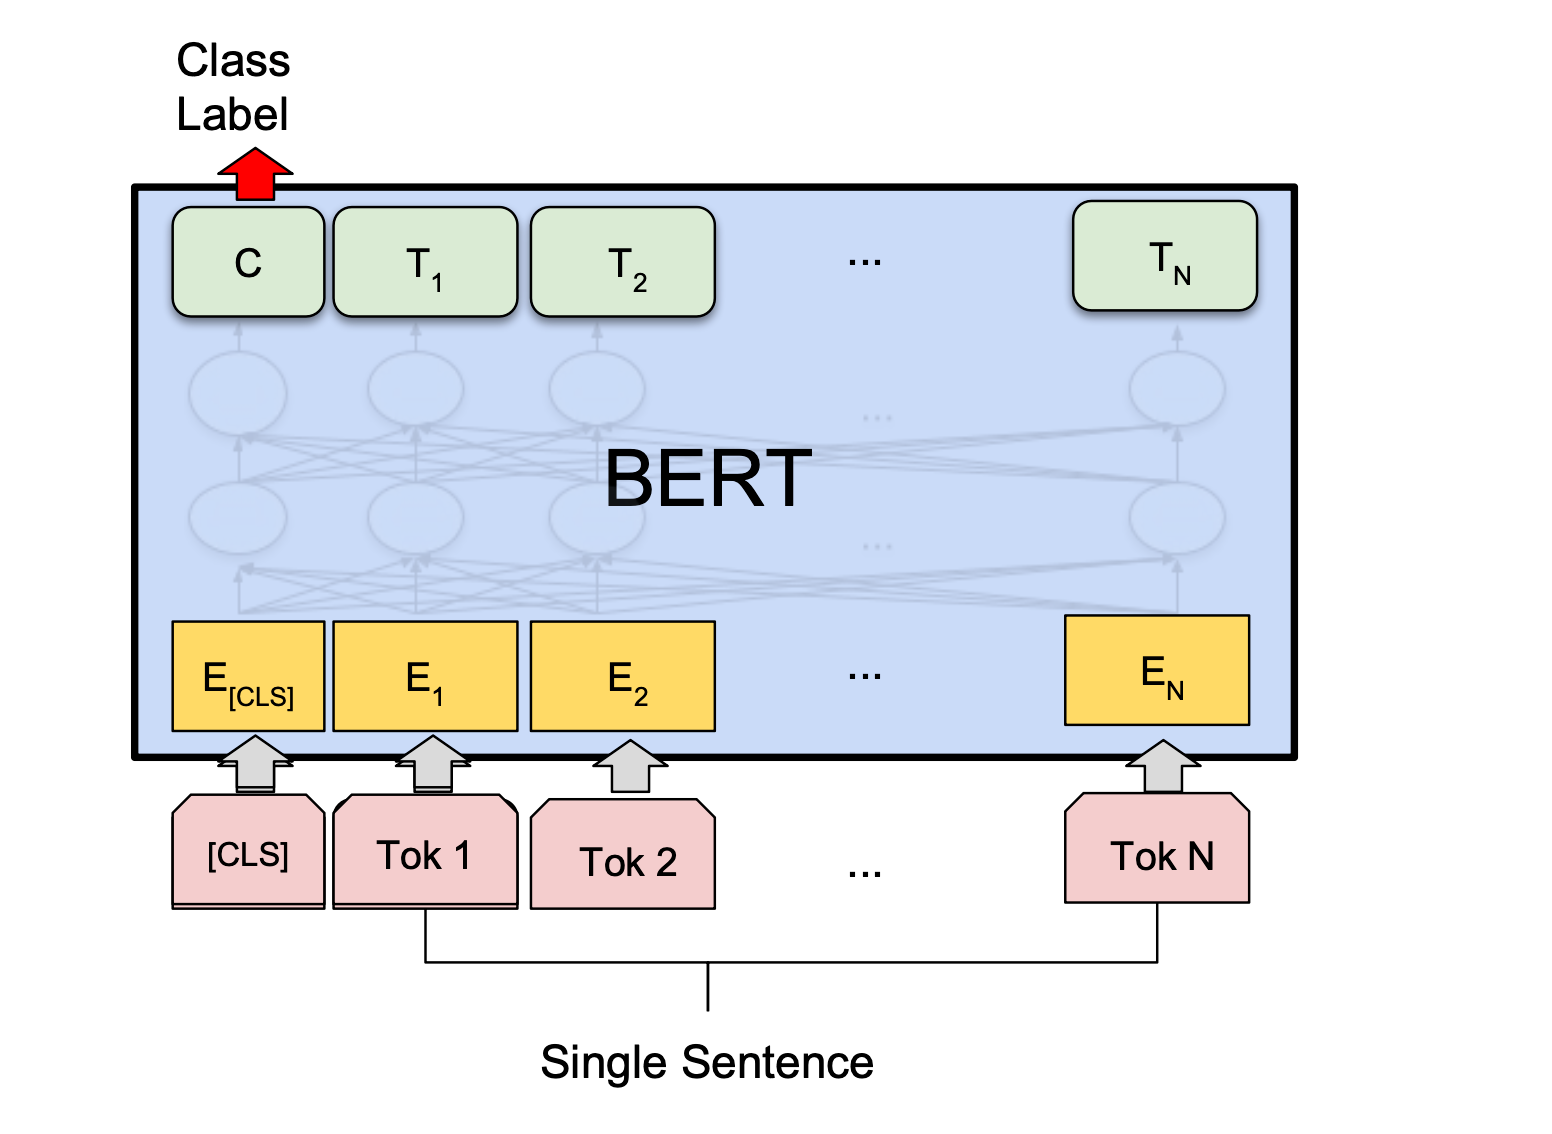

In [6]:
def print_encoding(model_inputs, indent=4):
    indent_str = " " * indent
    print("{")
    for k, v in model_inputs.items():
        print(indent_str + k + ":")
        print(indent_str + indent_str + str(v))
    print("}")

In [7]:
sample_text = "Atrial fibrillation is the most common cardiac arrhythmia. It affects millions of patients worldwide!"
tokenized_inputs = tokenizer(sample_text)

print_encoding(tokenized_inputs)

{
    input_ids:
        [101, 1335, 13119, 20497, 27647, 3848, 2116, 1110, 1103, 1211, 1887, 17688, 170, 11096, 7889, 1582, 8191, 119, 1135, 13974, 9215, 1104, 4420, 4529, 106, 102]
    token_type_ids:
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    attention_mask:
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}


In [8]:
cls = [tokenizer.cls_token_id]
sep = [tokenizer.sep_token_id]

# Tokenization happens in a few steps:
input_tokens = tokenizer.tokenize(sample_text)
input_ids = tokenizer.convert_tokens_to_ids(input_tokens)
input_ids_special_tokens = cls + input_ids + sep

decoded_str = tokenizer.decode(input_ids_special_tokens)

print("start:                ", sample_text)
print("tokenize:             ", input_tokens)
print("convert_tokens_to_ids:", input_ids)
print("add special tokens:   ", input_ids_special_tokens)
print("--------")
print("decode:               ", decoded_str)

# NOTE that these steps don't create the attention mask or add the special characters

start:                 Atrial fibrillation is the most common cardiac arrhythmia. It affects millions of patients worldwide!
tokenize:              ['At', '##rial', 'fi', '##bri', '##lla', '##tion', 'is', 'the', 'most', 'common', 'cardiac', 'a', '##rr', '##hy', '##th', '##mia', '.', 'It', 'affects', 'millions', 'of', 'patients', 'worldwide', '!']
convert_tokens_to_ids: [1335, 13119, 20497, 27647, 3848, 2116, 1110, 1103, 1211, 1887, 17688, 170, 11096, 7889, 1582, 8191, 119, 1135, 13974, 9215, 1104, 4420, 4529, 106]
add special tokens:    [101, 1335, 13119, 20497, 27647, 3848, 2116, 1110, 1103, 1211, 1887, 17688, 170, 11096, 7889, 1582, 8191, 119, 1135, 13974, 9215, 1104, 4420, 4529, 106, 102]
--------
decode:                [CLS] Atrial fibrillation is the most common cardiac arrhythmia. It affects millions of patients worldwide! [SEP]


In [9]:
# Other cool tricks:
# The tokenizer can return pytorch tensors
model_inputs = tokenizer(sample_text, return_tensors="pt")
print("PyTorch Tensors:")
print_encoding(model_inputs)

PyTorch Tensors:
{
    input_ids:
        tensor([[  101,  1335, 13119, 20497, 27647,  3848,  2116,  1110,  1103,  1211,
          1887, 17688,   170, 11096,  7889,  1582,  8191,   119,  1135, 13974,
          9215,  1104,  4420,  4529,   106,   102]])
    token_type_ids:
        tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]])
    attention_mask:
        tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1]])
}


## Batch of sentences

In [11]:
# You can pass multiple strings into the tokenizer and pad them as you need
model_inputs = tokenizer(["Atrial fibrillation increases the risk of stroke and requires anticoagulation.",
                         "The patient presented with shortness of breath, bilateral rales, and an elevated BNP, \
                         consistent with acute decompensated heart failure requiring diuresis and oxygen therapy.",
                         ],
                         return_tensors="pt",
                         padding=True,
                         truncation=True)
print(f"Pad token: {tokenizer.pad_token} | Pad token id: {tokenizer.pad_token_id}")
print("Padding:")
print_encoding(model_inputs)

Pad token: [PAD] | Pad token id: 0
Padding:
{
    input_ids:
        tensor([[  101,  1335, 13119, 20497, 27647,  3848,  2116,  6986,  1103,  3187,
          1104,  6625,  1105,  5315,  2848, 20535, 13830,  6840,   119,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101,  1109,  5351,  2756,  1114,  1603,  1757,  1104,  2184,   117,
         20557,   187, 19856,   117,  1105,  1126,  8208,   139, 14576,   117,
          8080,  1114, 12104,  1260,  8178, 11741, 28027,  1174,  1762,  4290,
          8753,  4267, 10374,  1548,  1105,  7621,  7606,   119,   102]])
    token_type_ids:
        tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
    atten

In [12]:
# You can also decode a whole batch at once:
print("Batch Decode:")
print(tokenizer.batch_decode(model_inputs.input_ids))
print()
print("Batch Decode: (no special characters)")
print(tokenizer.batch_decode(model_inputs.input_ids, skip_special_tokens=True))

Batch Decode:
['[CLS] Atrial fibrillation increases the risk of stroke and requires anticoagulation. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]', '[CLS] The patient presented with shortness of breath, bilateral rales, and an elevated BNP, consistent with acute decompensated heart failure requiring diuresis and oxygen therapy. [SEP]']

Batch Decode: (no special characters)
['Atrial fibrillation increases the risk of stroke and requires anticoagulation.', 'The patient presented with shortness of breath, bilateral rales, and an elevated BNP, consistent with acute decompensated heart failure requiring diuresis and oxygen therapy.']


### BPE in Practice: GPT-2 vs WordPiece (DistilBERT)

Now let's compare how a **real BPE tokenizer** (GPT-2) and a **WordPiece tokenizer** (DistilBERT, used above) segment the same biomedical terms. The key differences to watch for:

- GPT-2/BPE marks **word starts** with a `Ġ` (space) prefix on the first subword
- DistilBERT/WordPiece marks **word continuations** with a `##` prefix
- Rare biomedical terms will be split differently by each algorithm since they were trained on different corpora

In [13]:
from transformers import AutoTokenizer

gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")         # BPE
wp_tokenizer   = AutoTokenizer.from_pretrained("distilbert/distilbert-base-cased")  # WordPiece

medical_terms = [
    "electrocardiogram",
    "tachyarrhythmia",
    "cardiomyopathy",
    "metformin",
    "apixaban",
    "hypercholesterolemia",
    "myocardial infarction",
]

print(f"{'Term':<28} {'GPT-2 (BPE)':<45} {'DistilBERT (WordPiece)'}")
print("─" * 110)
for term in medical_terms:
    bpe_tokens = gpt2_tokenizer.tokenize(term)
    wp_tokens  = wp_tokenizer.tokenize(term)
    print(f"{term:<28} {str(bpe_tokens):<45} {str(wp_tokens)}")

print("\n💡 DistilBERT uses '##' for non-start pieces.")
print("   Differences reflect the corpora and vocabulary sizes each model was trained on.")


Term                         GPT-2 (BPE)                                   DistilBERT (WordPiece)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
electrocardiogram            ['elect', 'ro', 'card', 'i', 'ogram']         ['electro', '##card', '##io', '##gram']
tachyarrhythmia              ['t', 'achy', 'arr', 'h', 'yth', 'mia']       ['ta', '##chy', '##ar', '##r', '##hy', '##th', '##mia']
cardiomyopathy               ['card', 'i', 'omy', 'opathy']                ['card', '##io', '##my', '##op', '##athy']
metformin                    ['met', 'form', 'in']                         ['met', '##form', '##in']
apixaban                     ['ap', 'ix', 'aban']                          ['a', '##pi', '##xa', '##ban']
hypercholesterolemia         ['hyper', 'ch', 'olester', 'ole', 'mia']      ['h', '##yper', '##cho', '##les', '##tero', '##lem', '##ia']
myocardial infarction        ['my', 'ocard', 'ial', 'Ġinf', 'ar', 'ction'] ['my', '#

## Embeddings

In [ ]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel



# ---- 1. Access the raw embedding matrix ----
base_model = AutoModel.from_pretrained(name)   # same DistilBERT as above
embedding_matrix = base_model.embeddings.word_embeddings.weight  # (vocab_size, 768)
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"  vocab_size = {embedding_matrix.shape[0]:,}")
print(f"  d_model    = {embedding_matrix.shape[1]}")

# ---- 2. Look up embeddings for the first sentence ----
sample_text = "Atrial fibrillation is the most common cardiac arrhythmia. It affects millions of patients worldwide!"
tokenizer = AutoTokenizer.from_pretrained(name)
model_inputs = tokenizer(sample_text, return_tensors="pt")

input_ids = model_inputs.input_ids[0]          # (seq_len,)
tokens    = tokenizer.convert_ids_to_tokens(input_ids)

with torch.no_grad():
    token_embeds = embedding_matrix[input_ids]  # (seq_len, 768)

print(f"\nTokens: {tokens}")
print(f"Token embedding shape: {token_embeds.shape}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3259.15it/s]
DistilBertModel LOAD REPORT from: distilbert/distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix shape: torch.Size([28996, 768])
  vocab_size = 28,996
  d_model    = 768

Tokens: ['[CLS]', 'At', '##rial', 'fi', '##bri', '##lla', '##tion', 'increases', 'the', 'risk', 'of', 'stroke', 'and', 'requires', 'anti', '##coa', '##gu', '##lation', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Token embedding shape: torch.Size([39, 768])


/scratch/local/28488487/ipykernel_1362605/1573289813.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


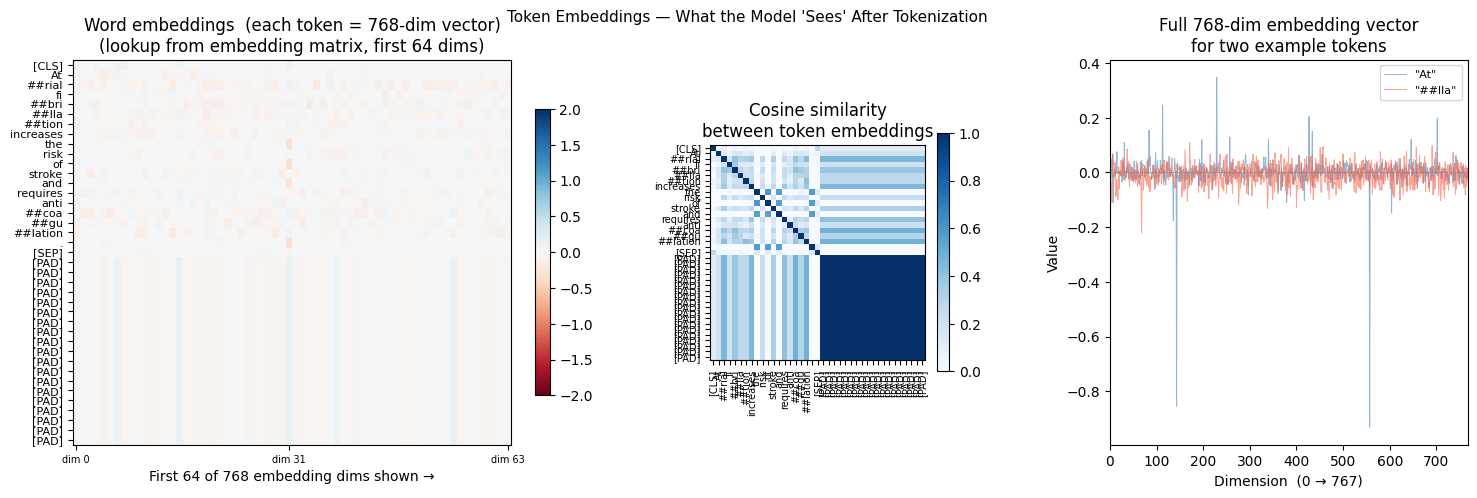


Each token is represented as a 768-dimensional float vector.
The full embedding matrix has shape (28996, 768)  (28,996 vocab tokens × 768 dims).

Note: at this stage all tokens are fully independent — they haven't attended to each other yet. That happens in the Transformer layers.


In [15]:

# ---- 3. Visualise ----
d_model = embedding_matrix.shape[1]   # 768 for DistilBERT-base

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5),
                                     gridspec_kw={"width_ratios": [2, 1, 1.5], "wspace": 0.45})

# (a) Heatmap of word embeddings (first 64 dims for readability)
im0 = ax0.imshow(token_embeds[:, :64].numpy(), aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
ax0.set_xticks([0, 31, 63])
ax0.set_xticklabels(["dim 0", "dim 31", "dim 63"], fontsize=7)
ax0.set_yticks(range(len(tokens)))
ax0.set_yticklabels(tokens, fontsize=8)
ax0.set_xlabel(f"First 64 of {d_model} embedding dims shown →")
ax0.set_title(f"Word embeddings  (each token = {d_model}-dim vector)\n(lookup from embedding matrix, first 64 dims)")
plt.colorbar(im0, ax=ax0, fraction=0.03)

# (b) Cosine similarity between token embeddings
n = len(tokens)
sim_matrix = torch.nn.functional.cosine_similarity(
    token_embeds.unsqueeze(1),   # (n, 1, 768)
    token_embeds.unsqueeze(0),   # (1, n, 768)
    dim=2
).numpy()
im1 = ax1.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
ax1.set_xticks(range(n)); ax1.set_xticklabels(tokens, rotation=90, fontsize=7)
ax1.set_yticks(range(n)); ax1.set_yticklabels(tokens, fontsize=7)
ax1.set_title("Cosine similarity\nbetween token embeddings")
plt.colorbar(im1, ax=ax1, fraction=0.05)

# (c) Full d_model-dim embedding vector for two example tokens
highlight_tokens = [ tokens[1], tokens[5]]  
highlight_idxs   = [0, 1]
colours = ["steelblue", "tomato"]
dims = torch.arange(d_model)
for tid, (tok_label, colour) in enumerate(zip(highlight_tokens, colours)):
    vec = token_embeds[highlight_idxs[tid]].numpy()
    ax2.plot(dims, vec, alpha=0.6, linewidth=0.7, color=colour, label=f'"{tok_label}"')
ax2.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax2.set_xlabel(f"Dimension  (0 → {d_model-1})")
ax2.set_ylabel("Value")
ax2.set_title(f"Full {d_model}-dim embedding vector\nfor two example tokens")
ax2.legend(fontsize=8)
ax2.set_xlim(0, d_model - 1)

plt.suptitle("Token Embeddings — What the Model 'Sees' After Tokenization", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nEach token is represented as a {d_model}-dimensional float vector.")
print(f"The full embedding matrix has shape {tuple(embedding_matrix.shape)}  "
      f"({embedding_matrix.shape[0]:,} vocab tokens × {d_model} dims).")
print("\nNote: at this stage all tokens are fully independent — "
      "they haven't attended to each other yet. That happens in the Transformer layers.")

###  Models




Initializing models is very similar to initializing tokenizers. You can either use the model class specific to your model or you can use an AutoModel class. I tend to prefer AutoModel, especially when I want to compare models, because it's easy to specify the models as strings.

While most of the pretrained transformers have similar architecture, if you there are additional weights, called "heads" that you have to train if you're doing sequence classification, question answering, or some other task. Hugging Face automatically sets up the architecture you need when you specify the model class. For example, we are doing sentiment analysis, so we are going to use `DistilBertForSequenceClassification`. If we were going to continue training DistilBERT on its masked-language modeling training objective, we would use `DistilBertForMaskedLM`, and if we just wanted the model's representations, maybe for our own downstream task, we could just use `DistilBertModel`.


Here's a stylized picture of a model recreated from one found here: [https://huggingface.co/course/chapter2/2?fw=pt](https://huggingface.co/course/chapter2/2?fw=pt).
![model_illustration.png](https://huggingface.co/datasets/huggingface-course/documentation-images/resolve/main/en/chapter2/transformer_and_head.svg)


Here are some examples.
```
*Model
*ForMaskedLM
*ForSequenceClassification
*ForTokenClassification
*ForQuestionAnswering
*ForMultipleChoice
...
```
where `*` can be `AutoModel` or a specific pretrained model (e.g. `DistilBert`)


There are three types of models:
* Encoders (e.g. BERT)
* Decoders (e.g. GPT2)
* Encoder-Decoder models (e.g. BART or T5)

The task-specific classes you have available depend on what type of model you're dealing with.


A full list of choices are available in the [docs](https://huggingface.co/docs/transformers/model_doc/auto). Note that not all models are compatible with all model architectures, for example DistilBERT is not compatible with the Seq2Seq models because it only consists of an encoder.


---

## Clinical NLP Example — Patient Outcome Prediction

### The Model: Bio_ClinicalBERT

**Bio_ClinicalBERT** ([Alsentzer et al., 2019](https://arxiv.org/abs/1904.03323)) is a domain-adapted BERT model pretrained on **~2 million de-identified clinical notes** from the MIMIC-III database (Beth Israel Deaconess Medical Center ICU). It was initialized from BioBERT (which was itself pretrained on PubMed + PMC biomedical literature) and then further pretrained on raw clinical notes.

Why does domain adaptation matter?

| Token | General BERT sees it as... | Bio_ClinicalBERT sees it as... |
|-------|---------------------------|-------------------------------|
| `BNP` | Rare / unknown | B-type natriuretic peptide (heart failure marker) |
| `EF` | Abbreviation | Ejection fraction (cardiac function) |
| `Lasix` | Unknown word | Loop diuretic (furosemide) |
| `dyspnea` | Rare medical term | Common symptom = shortness of breath |

---

### The Task: Clinical Outcome Classification

We frame the task as a **binary sequence classification** problem:

> Given a **clinical discharge summary**, predict whether the patient's condition was **IMPROVING** or **DETERIORATING** at the time of discharge.

```
Input:  "Patient presented with worsening dyspnea... discharged in stable condition..."
Output: IMPROVING (label = 1)  or  DETERIORATING (label = 0)
```

**Architecture:**

```
Clinical note (text)
        ↓
   Clinical Tokenizer
        ↓
  Bio_ClinicalBERT encoder  ← pretrained weights (frozen or fine-tuned)
  [ [CLS] token embedding ]
        ↓
  Linear classification head  ← randomly initialized, trained on labeled data
        ↓
  logits: [score_DETERIORATING, score_IMPROVING]
        ↓
  softmax → probabilities → argmax → predicted label
```

**Important:** In this demo the classification head weights are **randomly initialized** — the model has not been fine-tuned on any labeled outcome data. The encoder (Bio_ClinicalBERT) does understand clinical language, but the head is just random. In practice you would fine-tune on a labeled dataset such as:
- **i2b2 / n2c2** clinical NLP challenges
- **MIMIC-III** discharge summary labels
- Your own institutional EHR labels

In [12]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

# Bio_ClinicalBERT is pretrained on 2 million de-identified clinical notes from MIMIC-III
# It understands clinical jargon, abbreviations, and note structure far better than general BERT
CLINICAL_MODEL = "emilyalsentzer/Bio_ClinicalBERT"

print('Loading clinical tokenizer and base model...')

clinical_tokenizer = AutoTokenizer.from_pretrained(CLINICAL_MODEL)

base_model = AutoModel.from_pretrained(CLINICAL_MODEL)

print("Loading classification model (pretrained encoder + randomly-initialized classification head)")
model = AutoModelForSequenceClassification.from_pretrained(CLINICAL_MODEL, num_labels=2)
print("Done. Model has", sum(p.numel() for p in model.parameters()) // 1_000_000, "M parameters")

Loading clinical tokenizer and base model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 79408.86it/s]
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading classification model (pretrained encoder + randomly-initialized classification head)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 60698.60it/s]
BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those para

Done. Model has 108 M parameters


In [14]:
# Clinical discharge summary snippet — the kind of text Bio_ClinicalBERT was pretrained on
sample_text = (
    "Patient is a 68-year-old male with a history of CHF and type 2 DM who presented with "
    "worsening dyspnea and bilateral lower extremity edema. BNP was markedly elevated at 1450 pg/mL. "
    "Echo showed EF of 25%. Patient was diuresed with IV Lasix with significant symptomatic improvement "
    "and was discharged in stable condition on optimized guideline-directed medical therapy."
)

model_inputs = clinical_tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=512)

# Option 1 — explicit keyword arguments
model_outputs = model(input_ids=model_inputs.input_ids, attention_mask=model_inputs.attention_mask)

# Option 2 — unpack the tokenizer dict directly (keys match model keyword args)
model_outputs = model(**model_inputs)

print("Tokens:", clinical_tokenizer.convert_ids_to_tokens(model_inputs.input_ids[0]))
print()

print("Logits:", model_outputs.logits)
print()
print(f"Distribution over labels: {torch.softmax(model_outputs.logits, dim=1)}")

Tokens: ['[CLS]', 'patient', 'is', 'a', '68', '-', 'year', '-', 'old', 'male', 'with', 'a', 'history', 'of', 'ch', '##f', 'and', 'type', '2', 'd', '##m', 'who', 'presented', 'with', 'worse', '##ning', 'd', '##ys', '##p', '##nea', 'and', 'bilateral', 'lower', 'ex', '##tre', '##mity', 'ed', '##ema', '.', 'b', '##n', '##p', 'was', 'marked', '##ly', 'elevated', 'at', '145', '##0', 'p', '##g', '/', 'm', '##l', '.', 'echo', 'showed', 'e', '##f', 'of', '25', '%', '.', 'patient', 'was', 'di', '##ures', '##ed', 'with', 'i', '##v', 'las', '##ix', 'with', 'significant', 's', '##ym', '##pt', '##oma', '##tic', 'improvement', 'and', 'was', 'discharged', 'in', 'stable', 'condition', 'on', 'op', '##ti', '##mized', 'guide', '##line', '-', 'directed', 'medical', 'therapy', '.', '[SEP]']

Logits: tensor([[0.5009, 0.4730]], grad_fn=<AddmmBackward0>)

Distribution over labels: tensor([[0.5070, 0.4930]], grad_fn=<SoftmaxBackward0>)


In [15]:
# HuggingFace computes the loss automatically when you pass 'labels'
# Label 0 = DETERIORATING, Label 1 = IMPROVING
# This patient improved (discharged stable) -> label = 1
clinical_labels = ['DETERIORATING', 'IMPROVING']

model_inputs = clinical_tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=512)
model_inputs['labels'] = torch.tensor([1])   # ground truth: IMPROVING

model_outputs = model(**model_inputs)

print(model_outputs)
print()
print(f"Loss (cross-entropy): {model_outputs.loss.item():.4f}")

print(f"Predicted label:      {clinical_labels[model_outputs.logits.argmax()]}")
print("      In practice you would fine-tune on a labeled clinical dataset (e.g. i2b2, MIMIC-CXR labels).")

print("NOTE: The classification head weights are randomly initialized here.")

SequenceClassifierOutput(loss=tensor(0.7072, grad_fn=<NllLossBackward0>), logits=tensor([[0.5009, 0.4730]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

Loss (cross-entropy): 0.7072
Predicted label:      DETERIORATING
      In practice you would fine-tune on a labeled clinical dataset (e.g. i2b2, MIMIC-CXR labels).
NOTE: The classification head weights are randomly initialized here.


In [13]:
# You can also initialize with random weights (useful to understand architecture without pretrained weights)

from transformers import AutoConfig

# Load Bio_ClinicalBERT config and set number of output labels
configuration = AutoConfig.from_pretrained(CLINICAL_MODEL)
configuration.num_labels = 2

# Initializing a model with random weights from the configuration
random_model = AutoModelForSequenceClassification.from_config(configuration)
print("Randomly-initialized model config:", configuration.model_type)
print("Hidden size:", configuration.hidden_size, "| Layers:", configuration.num_hidden_layers, "| Heads:", configuration.num_attention_heads)

configuration = random_model.config
# Accessing the model configuration

Randomly-initialized model config: bert
Hidden size: 768 | Layers: 12 | Heads: 12


## Attention Visualization

In [16]:
from transformers import AutoModel

model = AutoModel.from_pretrained("distilbert-base-cased", output_attentions=True, output_hidden_states=True)
model.eval()
sample_text = "Atrial fibrillation is the most common cardiac arrhythmia. It affects millions of patients worldwide!"
model_inputs = tokenizer(sample_text, return_tensors="pt")
with torch.no_grad():
    model_output = model(**model_inputs)


print("Hidden state size (per layer):  ", model_output.hidden_states[0].shape)
print("Attention head size (per layer):", model_output.attentions[0].shape)     # (layer, batch, query_word_idx, key_word_idxs)
                                                                               # y-axis is query, x-axis is key
# print(model_output)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3088.38it/s]
DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hidden state size (per layer):   torch.Size([1, 26, 768])
Attention head size (per layer): torch.Size([1, 12, 26, 26])


['[CLS]', 'At', '##rial', 'fi', '##bri', '##lla', '##tion', 'is', 'the', 'most', 'common', 'cardiac', 'a', '##rr', '##hy', '##th', '##mia', '.', 'It', 'affects', 'millions', 'of', 'patients', 'worldwide', '!', '[SEP]']
Showing 2/6 layers and 4/12 heads


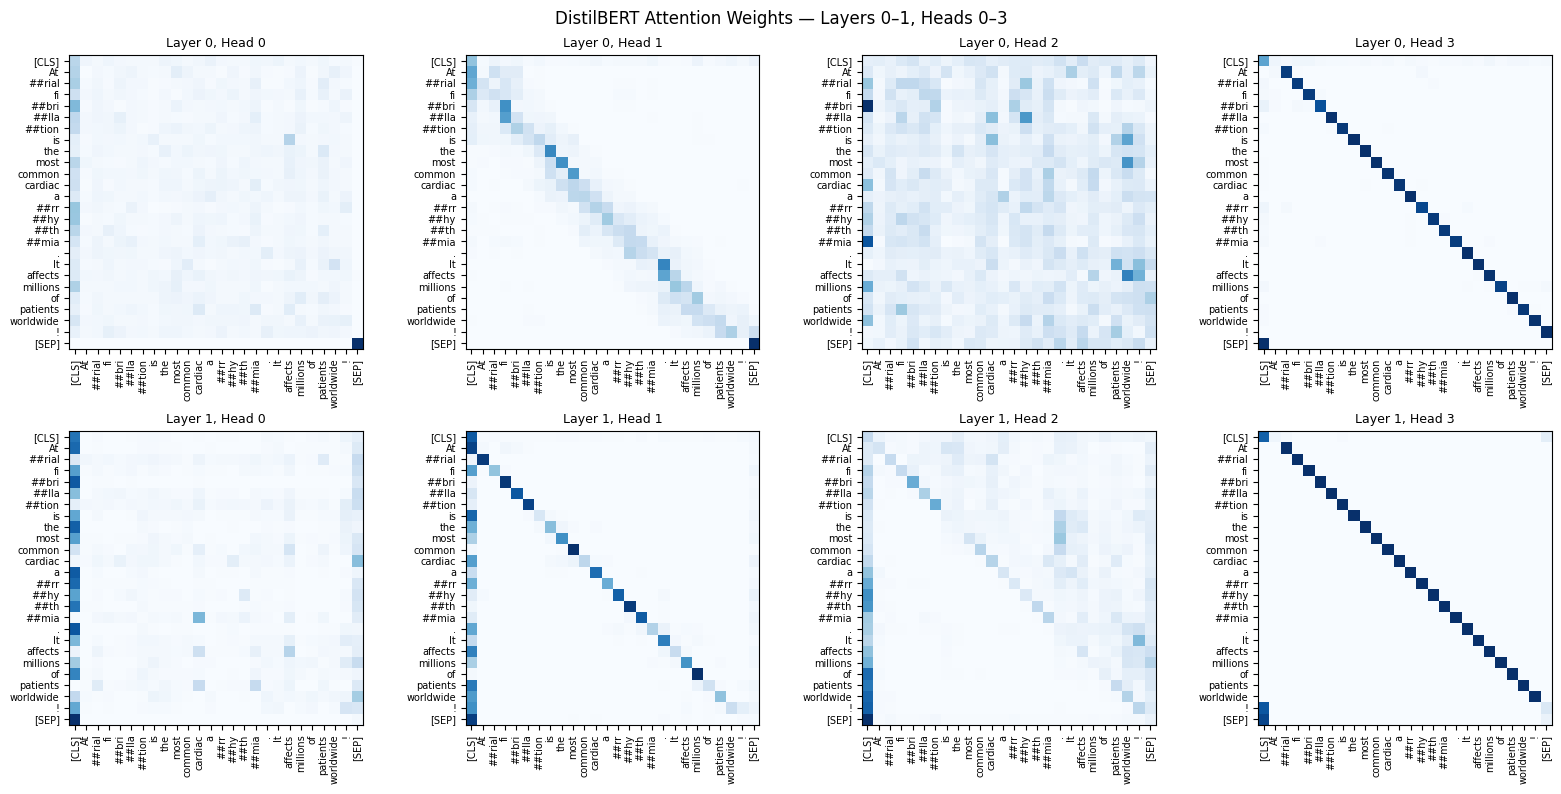

In [17]:
tokens = tokenizer.convert_ids_to_tokens(model_inputs.input_ids[0])
print(tokens)


n_layers = len(model_output.attentions)
n_heads  = model_output.attentions[0].shape[1]   # (batch, heads, seq, seq)
n_tokens = len(tokens)

# Show only a subset to keep the figure readable
show_layers = min(2, n_layers)   # first 2 layers
show_heads  = min(4, n_heads)    # first 4 heads
print(f"Showing {show_layers}/{n_layers} layers and {show_heads}/{n_heads} heads")

fig, axes = plt.subplots(show_layers, show_heads, figsize=(show_heads * 4, show_layers * 4))
for layer in range(show_layers):
    for i in range(show_heads):
        ax = axes[layer, i]
        ax.imshow(model_output.attentions[layer][0, i].numpy(), cmap="Blues")
        ax.set_xticks(range(n_tokens))
        ax.set_xticklabels(tokens, rotation=90, fontsize=7)
        ax.set_yticks(range(n_tokens))
        ax.set_yticklabels(tokens, fontsize=7)
        ax.set_title(f"Layer {layer}, Head {i}", fontsize=9)

plt.suptitle(f"DistilBERT Attention Weights — Layers 0–{show_layers-1}, Heads 0–{show_heads-1}", fontsize=12)
plt.tight_layout()
plt.show()

---

### 3. GPT-2 — Decoder-Only Transformer

**GPT** (Generative Pre-trained Transformer, Radford et al., 2018 / 2019) uses **only the Transformer decoder** with one critical modification: cross-attention is removed (there is no encoder to attend to). The result is a **causal language model** that generates text left-to-right.

**Key ideas:**

1. **Causal (masked) self-attention:** Each token can only attend to **previous tokens** — future positions are masked with $-\infty$ before softmax.
2. **Pretraining objective:** Predict the next token given all previous tokens (standard language modeling):
$$\mathcal{L} = -\sum_{t} \log P(x_t \mid x_1, \ldots, x_{t-1})$$
3. **No [CLS] token:** The representation of the **last** token is typically used for classification tasks.
4. **Scaling laws:** GPT family (GPT-2 → GPT-3 → GPT-4) shows that performance improves predictably with more parameters + data + compute.

**Complexity:** Same $O(n^2 \cdot d)$ attention per layer, but the causal mask means during *inference* each new token only attends to past tokens (often cached via KV-cache → $O(n \cdot d)$ incremental cost).

**KV-Cache:** During autoregressive generation, previously computed key/value matrices are cached, so each new token only computes one new attention row instead of the full $n \times n$ matrix — greatly accelerating generation.

**When to use GPT-style models:**
- Text generation, code completion, summarization, instruction following
- Any task where the output is a **sequence generated token-by-token**
- Modern LLMs (LLaMA, Mistral, Falcon) are all decoder-only

**BERT vs GPT at a glance:**

| | BERT (encoder-only) | GPT (decoder-only) |
|--|--------------------|--------------------|
| Attention | Bidirectional (all tokens) | Causal (past tokens only) |
| Pretraining | Masked LM + NSP | Next-token prediction |
| Strength | Understanding | Generation |
| Fine-tuning head | Classifier on [CLS] | Generative head on last token |

In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Define tokenizer and prompt here so this cell is self-contained
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
prompt   = "Atrial fibrillation is a condition where"

# Reload GPT-2 with attention outputs enabled
gpt2_attn_model = AutoModelForCausalLM.from_pretrained("gpt2", output_attentions=True)
gpt2_attn_model.eval()

gpt2_inputs = gpt2_tok(prompt, return_tensors="pt")
with torch.no_grad():
    gpt2_output = gpt2_attn_model(**gpt2_inputs)

gpt2_tokens = gpt2_tok.convert_ids_to_tokens(gpt2_inputs.input_ids[0])
print("Tokens:", gpt2_tokens)
print(f"\nNumber of layers:  {len(gpt2_output.attentions)}")
print(f"Attention shape (batch, heads, seq, seq): {gpt2_output.attentions[0].shape}")

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 20979.32it/s]

Tokens: ['At', 'rial', 'Ġf', 'ibr', 'illation', 'Ġis', 'Ġa', 'Ġcondition', 'Ġwhere']

Number of layers:  12
Attention shape (batch, heads, seq, seq): torch.Size([1, 12, 9, 9])


In [19]:
print(gpt2_tok)
# print special token ids


GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})


Showing 2/12 layers and 4/12 heads


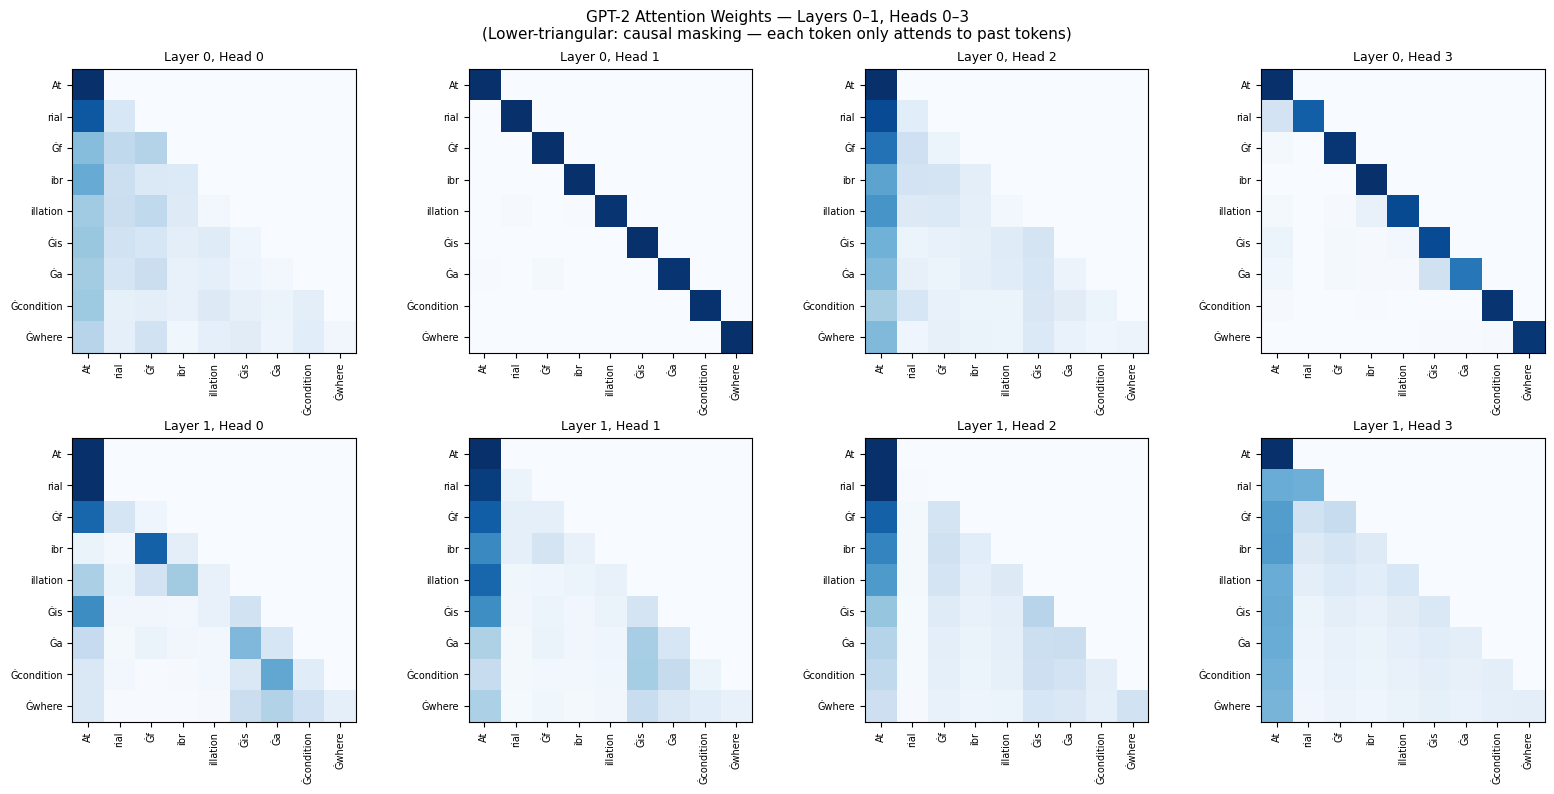

In [20]:
import matplotlib.pyplot as plt
import numpy as np

n_layers_gpt2 = len(gpt2_output.attentions)
n_heads_gpt2  = gpt2_output.attentions[0].shape[1]
n_tokens_gpt2 = len(gpt2_tokens)

show_layers = min(2, n_layers_gpt2)
show_heads  = min(4, n_heads_gpt2)
print(f"Showing {show_layers}/{n_layers_gpt2} layers and {show_heads}/{n_heads_gpt2} heads")

fig, axes = plt.subplots(show_layers, show_heads, figsize=(show_heads * 4, show_layers * 4))
for layer in range(show_layers):
    for h in range(show_heads):
        ax = axes[layer, h]
        attn = gpt2_output.attentions[layer][0, h].numpy()
        ax.imshow(attn, cmap="Blues", vmin=0, vmax=attn.max())
        ax.set_xticks(range(n_tokens_gpt2))
        ax.set_xticklabels(gpt2_tokens, rotation=90, fontsize=7)
        ax.set_yticks(range(n_tokens_gpt2))
        ax.set_yticklabels(gpt2_tokens, fontsize=7)
        ax.set_title(f"Layer {layer}, Head {h}", fontsize=9)

plt.suptitle(
    f"GPT-2 Attention Weights — Layers 0–{show_layers-1}, Heads 0–{show_heads-1}\n"
    "(Lower-triangular: causal masking — each token only attends to past tokens)",
    fontsize=11
)
plt.tight_layout()
plt.show()

---

### 2. ViT — Vision Transformer (Encoder-Only for Images)

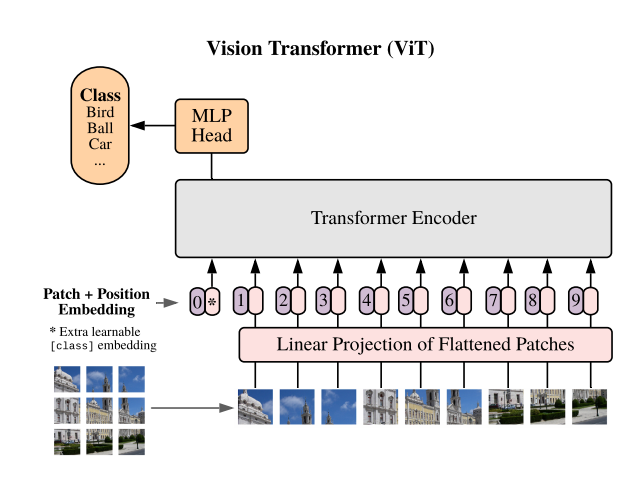


**ViT** (Dosovitskiy et al., 2020) applies the standard Transformer encoder to images by splitting them into fixed-size **patches** and treating each patch as a "token".

**Key ideas:**

1. **Patch embedding:** An image of size $H \times W$ is divided into $N = \frac{H \cdot W}{P^2}$ non-overlapping patches of size $P \times P$.
2. Each patch is linearly projected to a $d$-dimensional embedding → replaces word embeddings.
3. A learnable **[CLS] token** is prepended (same as BERT) — its final hidden state is used for classification.
4. **Positional embeddings** are added to retain spatial information.
5. Standard Transformer encoder blocks (Multi-head Self-Attention + FFN) process the sequence of patch embeddings.

$$N = \frac{H \times W}{P^2}, \quad \text{e.g. } \frac{224 \times 224}{16^2} = 196 \text{ patches for a } 224\text{px image}$$

**Complexity:** Same $O(N^2 \cdot d)$ self-attention — but $N$ is determined by image resolution and patch size, not text length.

**When to use ViT:**
- Image classification, medical imaging (pathology slides, chest X-rays)
- Works best with large amounts of pretraining data (ImageNet-21k, JFT-300M)
- **BEiT** and **DeiT** improve data efficiency via masked image modeling / distillation

**ViT vs CNN:**

| Property | CNN | ViT |
|----------|-----|-----|
| Inductive bias | Strong (locality, translation eq.) | Weak (learns from data) |
| Global context | Limited (large kernels / deep nets) | Full (all patches attend to each other) |
| Data requirement | Lower | Higher (or needs pretraining) |
| Scalability | Good | Excellent at scale |

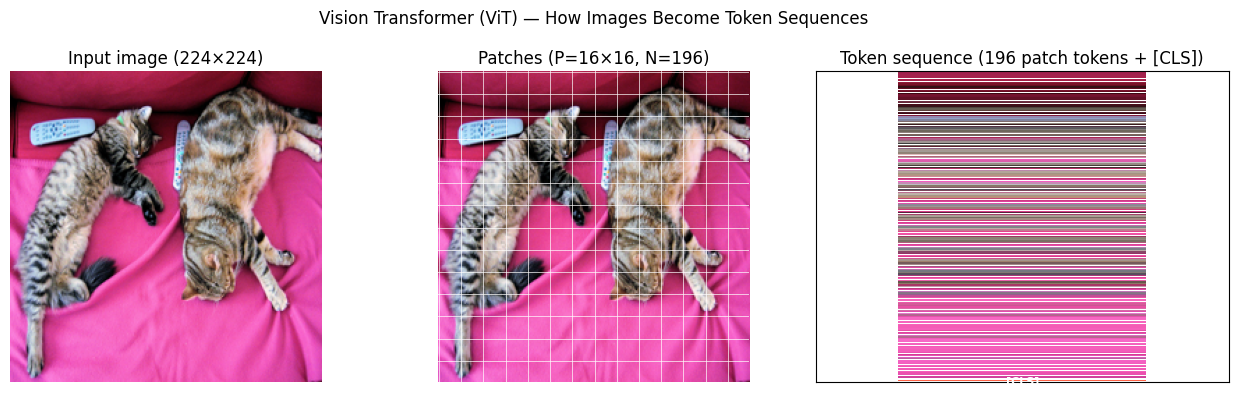


--- Running google/vit-base-patch16-224 ---


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 2583.34it/s]


Pixel values shape: torch.Size([1, 3, 224, 224])

Top-5 predictions:
  Egyptian cat                   score=12.419
  tabby, tabby cat               score=9.225
  tiger cat                      score=8.243
  lynx, catamount                score=6.762
  Siamese cat, Siamese           score=5.189


In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import requests
from transformers import ViTImageProcessor, ViTForImageClassification

# ---- 0. Download a real image to use throughout ----
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image_224 = image.resize((224, 224))
img_array = np.array(image_224) / 255.0   # (224, 224, 3) float in [0,1]

# ---- 1. Visualise the patch-splitting idea ----
img_size, patch_size = 224, 16
n_patches_side = img_size // patch_size   # 14 per side -> 196 patches

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Left: real image
axes[0].imshow(img_array)
axes[0].set_title("Input image (224×224)")
axes[0].axis("off")

# Middle: same image with patch grid overlay
axes[1].imshow(img_array)
for i in range(0, img_size, patch_size):
    axes[1].axhline(i, color="white", linewidth=0.6, alpha=0.8)
    axes[1].axvline(i, color="white", linewidth=0.6, alpha=0.8)
axes[1].set_title(f"Patches (P={patch_size}×{patch_size}, N={n_patches_side**2})")
axes[1].axis("off")

# Right: schematic token sequence
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, n_patches_side**2 + 2)
# colour each bar by the average colour of the corresponding patch
patch_colours = []
for row in range(n_patches_side):
    for col in range(n_patches_side):
        patch = img_array[row*patch_size:(row+1)*patch_size,
                          col*patch_size:(col+1)*patch_size]
        patch_colours.append(patch.mean(axis=(0, 1)))   # average RGB

axes[2].barh(range(n_patches_side**2), [0.6]*n_patches_side**2,
             color=patch_colours, left=0.2)
axes[2].barh(n_patches_side**2 + 1, 0.6, left=0.2, color="tomato")
axes[2].text(0.5, n_patches_side**2 + 1, "[CLS]",
             va="center", ha="center", fontsize=8, color="white", fontweight="bold")
axes[2].set_yticks([])
axes[2].set_xticks([])
axes[2].set_title("Token sequence (196 patch tokens + [CLS])")
axes[2].invert_yaxis()

plt.suptitle("Vision Transformer (ViT) — How Images Become Token Sequences", fontsize=12)
plt.tight_layout()
plt.show()

# ---- 2. Run a real ViT model on the same image ----
print("\n--- Running google/vit-base-patch16-224 ---")
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

inputs = processor(images=image, return_tensors="pt")
print("Pixel values shape:", inputs["pixel_values"].shape)   # (1, 3, 224, 224)

with torch.no_grad():
    logits = vit_model(**inputs).logits

top5 = logits[0].topk(5)
print("\nTop-5 predictions:")
for score, idx in zip(top5.values, top5.indices):
    label = vit_model.config.id2label[idx.item()]
    print(f"  {label:<30} score={score.item():.3f}")


---

## Sources & Acknowledgements

Portions of the code and conceptual material in this notebook are adapted from the **Stanford CS224N: Natural Language Processing with Deep Learning** course materials, used here for educational purposes.

- **Course:** CS224N — NLP with Deep Learning, Stanford University
- **Instructors:** Christopher Manning et al.
- **URL:** https://web.stanford.edu/class/cs224n/